# Data Cleaning
**ShipmentSure — Predicting On-Time Delivery**

This notebook covers the first reliability baseline of the dataset:
- Data types, structure, and summary statistics
- Missing value and duplicate detection
- Outlier and correlation analysis
- Column-level data quality checks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load dataset
df = pd.read_csv('../data/Train.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
# Data types and structure
print("Data Types:")
print(df.dtypes)
print("\nInfo:")
df.info()

Data Types:
ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   1000 non-null   int64 
 1   Warehouse_block      1000 non-null   object
 2   Mode_of_Shipment     1000 non-null   object
 3   Customer_care_calls  1000 non-null   int64 
 4   Customer_rating      1000 non-null   int64 
 5   Cost_of_the_Product  1000 non-null   int64 
 6   Prior_purchases      1000 non-null   int64 
 7   Product_importance   1000 non-null   object
 8   Gender

In [4]:
# Summary statistics
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,4.523000,2.981000,200.316000,5.984000,31.987000,3501.413000,0.505000
std,288.819436,1.731031,1.424313,62.730178,2.574174,18.506737,1407.924646,0.500225
min,1.000000,2.000000,1.000000,90.000000,2.000000,1.000000,1005.000000,0.000000
25%,250.750000,3.000000,2.000000,146.000000,4.000000,16.000000,2271.250000,0.000000
50%,500.500000,5.000000,3.000000,202.500000,6.000000,32.000000,3544.000000,1.000000
75%,750.250000,6.000000,4.000000,254.000000,8.000000,48.000000,4683.250000,1.000000
max,1000.000000,7.000000,5.000000,309.000000,10.000000,64.000000,5988.000000,1.000000


In [5]:
# Categorical column summaries
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Categorical columns:", list(cat_cols))
print("Numeric columns:", list(num_cols))

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts())

Categorical columns: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
Numeric columns: ['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']

Warehouse_block: 5 unique values
Warehouse_block
C    214
D    213
A    197
F    196
B    180
Name: count, dtype: int64

Mode_of_Shipment: 3 unique values
Mode_of_Shipment
Road      345
Ship      333
Flight    322
Name: count, dtype: int64

Product_importance: 3 unique values
Product_importance
low       353
medium    325
high      322
Name: count, dtype: int64

Gender: 2 unique values
Gender
F    516
M    484
Name: count, dtype: int64


In [6]:
# Missing value detection
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

Total missing values: 0


In [7]:
# Duplicate row detection
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
if dup_count > 0:
    df = df.drop_duplicates()
    print(f"After removal: {df.shape}")

Duplicate rows: 0


In [8]:
# Unique value count per column
print("Unique values per column:")
print(df.nunique())

Unique values per column:
ID                     1000
Warehouse_block           5
Mode_of_Shipment          3
Customer_care_calls       6
Customer_rating           5
Cost_of_the_Product     220
Prior_purchases           9
Product_importance        3
Gender                    2
Discount_offered         64
Weight_in_gms           903
Reached.on.Time_Y.N       2
dtype: int64


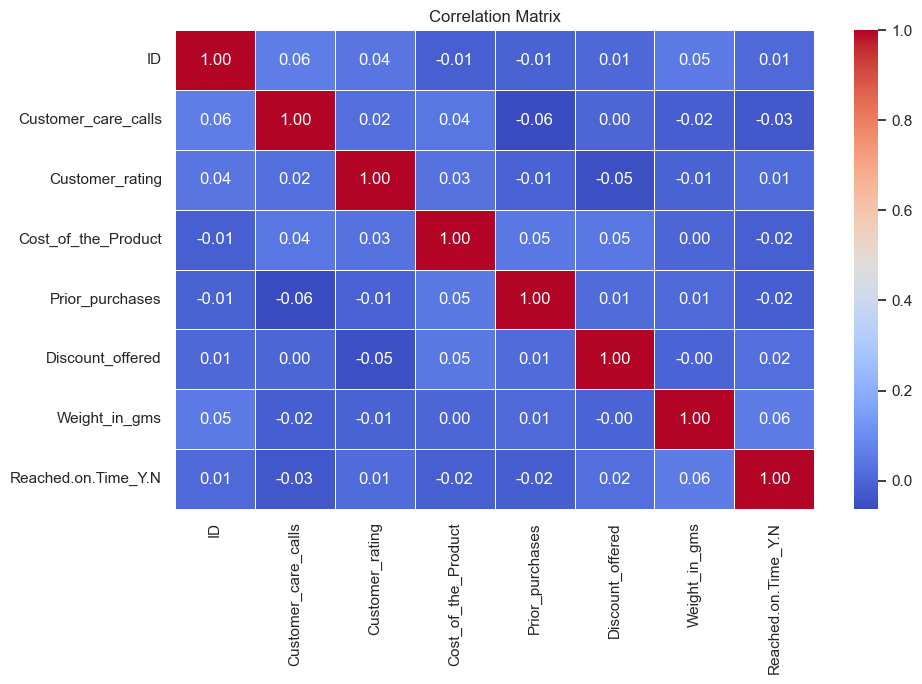

In [9]:
# Correlation heatmap (numeric features)
plt.figure(figsize=(10, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

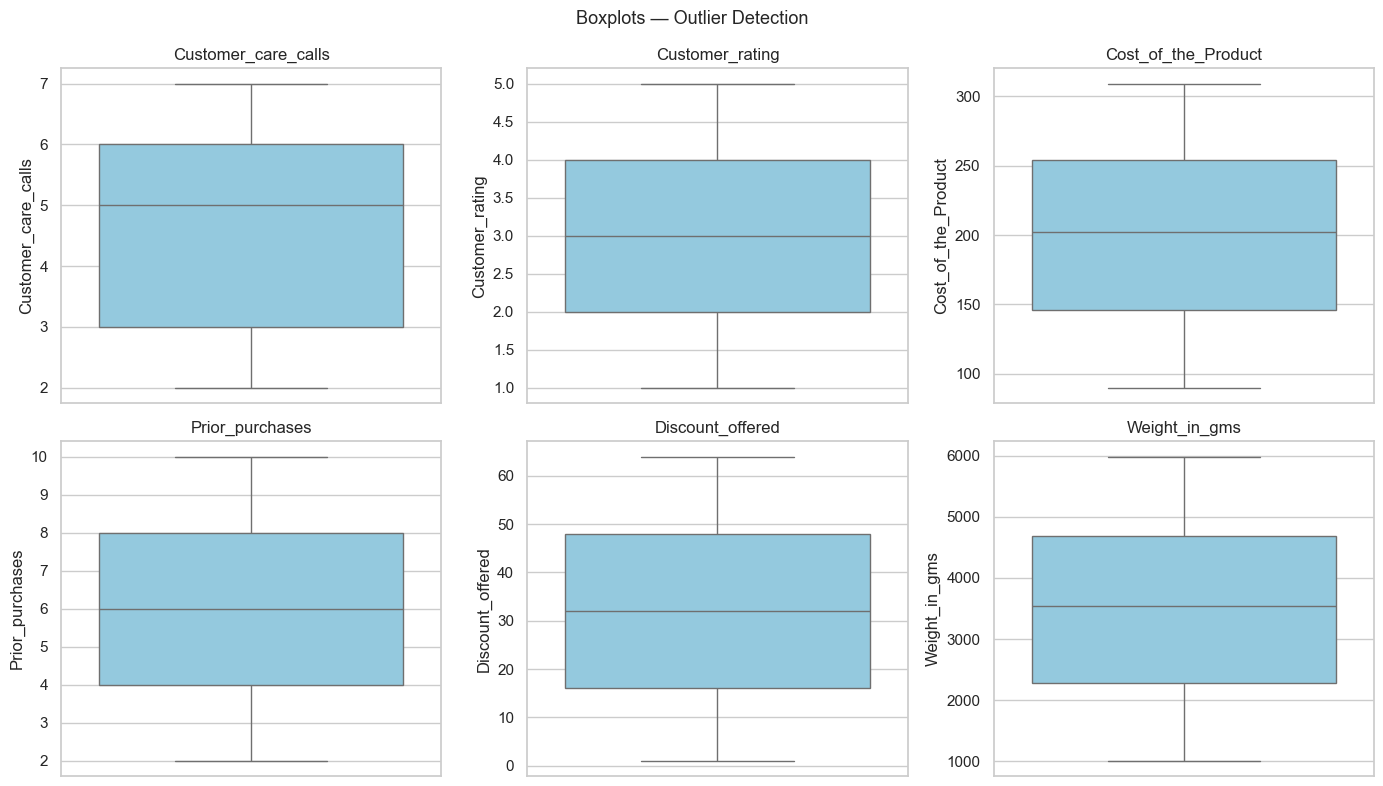

In [10]:
# Boxplots for outlier detection
numeric_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
                'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Boxplots — Outlier Detection', fontsize=13)

for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 3][idx % 3]
    sns.boxplot(data=df, y=col, ax=ax, color='skyblue')
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [11]:
# Target column distribution
print("Target distribution (Reached.on.Time_Y.N):")
print(df['Reached.on.Time_Y.N'].value_counts())
print(f"\n0 = Not on time, 1 = On time")
print(f"On-time delivery rate: {df['Reached.on.Time_Y.N'].mean():.2%}")

Target distribution (Reached.on.Time_Y.N):
Reached.on.Time_Y.N
1    505
0    495
Name: count, dtype: int64

0 = Not on time, 1 = On time
On-time delivery rate: 50.50%
